# Phân rã theo band giá — cả 3 phương pháp × 3 mức tin cậy

> **Ý 1 trong feedback tuần 3 của mentor:**
>
> *"thay vì chung chung model mình chính xác tới mức nào… anh nghĩ nên phân rã ra"*

`uncertainty/07` đã phân rã theo band giá cho **một** phương pháp ở **một** mức tin cậy
(Conformal, 90%) và tìm ra: band >300k coverage chỉ **82,5%** so với danh mục 90%.

Notebook này hỏi câu tiếp theo: **đó là vấn đề của Conformal, hay của cả ba phương pháp?**

Nếu cả ba đều hụt ở band cao ⇒ đó là **tính chất của dữ liệu**, đổi phương pháp không cứu được.
Nếu chỉ Conformal hụt ⇒ **chọn sai phương pháp**.

> **Kết quả: vế thứ hai.** Xem mục 5. Điều này **sửa lại** kết luận tuần 3 — lúc đó chọn Conformal
> vì coverage tổng thể và độ rộng tốt, nhưng chưa nhìn coverage theo band.

## Ma trận cần điền

| | 70% | 80% | 90% |
|---|---|---|---|
| Conformal chuẩn hoá | | | |
| QR thô | | | |
| CQR | | | |

Mỗi ô là một bảng 6 band → **54 dòng** kết quả.

In [1]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
%matplotlib inline

BLUE, ORANGE, GREEN, RED, PURPLE, MUT = ("#0072B2", "#E69F00", "#009E73",
                                         "#D55E00", "#CC79A7", "#666666")
INK = "#222222"
plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": .25,
    "savefig.dpi": 150, "savefig.bbox": "tight",
    "font.size": 11.5, "axes.titlesize": 13, "axes.labelsize": 11.5,
    "xtick.labelsize": 10.5, "ytick.labelsize": 10.5, "legend.fontsize": 10.5,
})
EVAL = Path("../evaluation")
HINH = Path("../../docs/hinh_anh"); HINH.mkdir(parents=True, exist_ok=True)

CANH = [0, 50e3, 100e3, 150e3, 200e3, 300e3, np.inf]
TEN = ["<50k", "50–100k", "100–150k", "150–200k", "200–300k", ">300k"]
MUC_PV = {0.90: ("q05", "q95"), 0.80: ("q10", "q90"), 0.70: ("q15", "q85")}
MUCS = [0.70, 0.80, 0.90]

uc = pd.read_parquet(EVAL / "uq_pred_calibration.parquet")
ut = pd.read_parquet(EVAL / "uq_pred_test.parquet")
qc = pd.read_parquet(EVAL / "qr_pred_da_muc_calibration.parquet")
qt = pd.read_parquet(EVAL / "qr_pred_da_muc_test.parquet")

# BAT BUOC: bon file phai cung thu tu hang thi moi gan band chung duoc
assert len(uc) == len(qc) and len(ut) == len(qt), "so dong lech"
assert np.allclose(uc.gia_that.values, qc.gia_that.values), "calibration lech hang"
assert np.allclose(ut.gia_that.values, qt.gia_that.values), "test lech hang"
print(f"Hang khop: calibration {len(uc):,} · test {len(ut):,}")

# Band dinh nghia bang MOT nguon duy nhat (gia du doan cua Hybrid),
# de ba phuong phap duoc so tren cung cach chia — khong ai duoc loi the.
for d, nguon in [(uc, uc), (ut, ut), (qc, uc), (qt, ut)]:
    d["band"] = pd.cut(nguon.hybrid_pred.values, CANH, labels=TEN, right=False)
print("\nSo chuyen tung band (tap test):")
print(ut.band.value_counts().reindex(TEN).to_string())

Hang khop: calibration 615,908 · test 864,360

So chuyen tung band (tap test):
band
<50k         10821
50–100k     264201
100–150k    409883
150–200k    149324
200–300k     28875
>300k         1256


## 1. Tính khoảng cho cả 9 tổ hợp

Ba phương pháp:

| Phương pháp | Cách dựng khoảng | Bảo đảm |
|---|---|---|
| **Conformal chuẩn hoá** | `q = phân vị(\|sai số\|/dự đoán)` trên calibration → `p̂ × (1 ± q)` | Hữu hạn mẫu |
| **QR thô** | Lấy thẳng 2 phân vị của model quantile | ❌ Không |
| **CQR** | Hiệu chỉnh 2 phân vị bằng conformity score trên calibration | Hữu hạn mẫu |

In [2]:
def khoang(muc):
    """Tra ve dict: ten phuong phap -> (can duoi, can tren) tren tap TEST."""
    lo_a, hi_a = MUC_PV[muc]
    out = {}

    # 1. Conformal chuan hoa
    e = ((uc.hybrid_pred - uc.gia_that).abs() / uc.hybrid_pred).values
    q = np.quantile(e, muc)
    out["Conformal"] = (ut.hybrid_pred*(1-q), ut.hybrid_pred*(1+q))

    # 2. QR tho — lay thang, khong hieu chinh
    out["QR thô"] = (qt[lo_a], qt[hi_a])

    # 3. CQR — hieu chinh bang conformity score
    E = np.maximum(qc[lo_a] - qc.gia_that, qc.gia_that - qc[hi_a]).values
    k = min(int(np.ceil((len(qc)+1)*muc)), len(qc))
    qq = np.sort(E)[k-1]
    out["CQR"] = (qt[lo_a] - qq, qt[hi_a] + qq)
    return out


def do_band(lo, hi, muc):
    """Bang chi tiet theo band cho 1 khoang."""
    d = pd.DataFrame({"band": ut.band.values, "y": ut.gia_that.values,
                      "p": ut.hybrid_pred.values,
                      "lo": np.asarray(lo), "hi": np.asarray(hi)})
    d["trong"] = (d.y >= d.lo) & (d.y <= d.hi)
    d["rong"] = d.hi - d.lo
    d["tren"] = d.y > d.hi          # that CAO hon can tren -> model hua thap
    d["duoi"] = d.y < d.lo
    g = d.groupby("band", observed=True).agg(
        n=("y", "size"), cvg=("trong", "mean"),
        rong_tb=("rong", "mean"), rong_td=("rong", "median"),
        p_tb=("p", "mean"), hut_tren=("tren", "mean"), hut_duoi=("duoi", "mean")
    ).reindex(TEN)
    g["lech"] = (g.cvg - muc) * 100
    g["rong_tuong_doi"] = g.rong_tb / g.p_tb
    return g


BANG = {}
for muc in MUCS:
    for ten_pp, (lo, hi) in khoang(muc).items():
        BANG[(ten_pp, muc)] = do_band(lo, hi, muc)

print(f"Da tinh {len(BANG)} to hop x 6 band = {len(BANG)*6} dong ket qua")

Da tinh 9 to hop x 6 band = 54 dong ket qua


## 2. Ma trận tổng — lệch coverage tối đa của từng ô

Một con số cho mỗi ô: **band nào lệch danh mục nhiều nhất, lệch bao nhiêu điểm**.
Đây là thước đo **coverage điều kiện** — coverage tổng thể có thể đẹp mà vẫn giấu một band tệ.

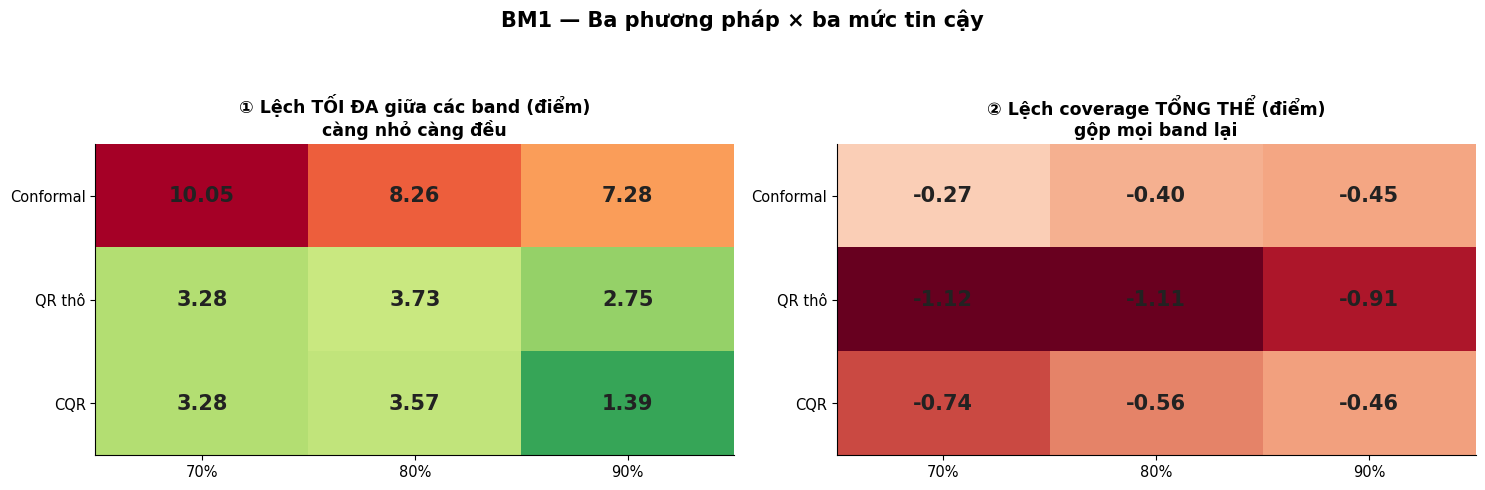

Phuong phap                   70%                80%                90%
------------------------------------------------------------------------
Conformal        tong -0.27 | max 10.05   tong -0.40 | max 8.26   tong -0.45 | max 7.28
QR thô           tong -1.12 | max 3.28   tong -1.11 | max 3.73   tong -0.91 | max 2.75
CQR              tong -0.74 | max 3.28   tong -0.56 | max 3.57   tong -0.46 | max 1.39

tong = lech coverage gop moi band · max = lech lon nhat cua mot band rieng le


In [3]:
# ═════════ HINH BM1 — ma tran 3 phuong phap x 3 muc ═════════
PP = ["Conformal", "QR thô", "CQR"]
M = np.zeros((len(PP), len(MUCS)))
TONG = np.zeros((len(PP), len(MUCS)))
for i, pp in enumerate(PP):
    for j, muc in enumerate(MUCS):
        g = BANG[(pp, muc)]
        M[i, j] = g.lech.abs().max()
        TONG[i, j] = (g.cvg * g.n).sum() / g.n.sum() * 100

fig, ax = plt.subplots(1, 2, figsize=(15, 4.6))
for a, dat, ten, fmt in [
        (ax[0], M, "① Lệch TỐI ĐA giữa các band (điểm)\ncàng nhỏ càng đều", "{:.2f}"),
        (ax[1], TONG - np.array(MUCS)*100,
         "② Lệch coverage TỔNG THỂ (điểm)\ngộp mọi band lại", "{:+.2f}")]:
    im = a.imshow(dat, cmap="RdYlGn_r" if ten.startswith("①") else "RdBu",
                  aspect="auto",
                  vmin=0 if ten.startswith("①") else -abs(dat).max(),
                  vmax=abs(dat).max())
    a.set_xticks(range(len(MUCS)))
    a.set_xticklabels([f"{m:.0%}" for m in MUCS])
    a.set_yticks(range(len(PP))); a.set_yticklabels(PP)
    for i in range(len(PP)):
        for j in range(len(MUCS)):
            a.text(j, i, fmt.format(dat[i, j]), ha="center", va="center",
                   fontsize=15, fontweight="bold", color=INK)
    a.set_title(ten, fontweight="bold", fontsize=12.5)
    a.grid(False)

fig.suptitle("BM1 — Ba phương pháp × ba mức tin cậy", fontweight="bold",
             fontsize=15, y=1.06)
plt.tight_layout(); plt.savefig(HINH / "BM1_ma_tran_3pp_3muc.png"); plt.show()

print(f"{'Phuong phap':14s} " + " ".join(f"{m:>18.0%}" for m in MUCS))
print("-" * 72)
for i, pp in enumerate(PP):
    print(f"{pp:14s} " + " ".join(
        f"  tong {TONG[i,j]-MUCS[j]*100:+5.2f} | max {M[i,j]:4.2f}" for j in range(len(MUCS))))
print()
print("tong = lech coverage gop moi band · max = lech lon nhat cua mot band rieng le")

## 3. Coverage theo band — nhìn thẳng vào chỗ hỏng

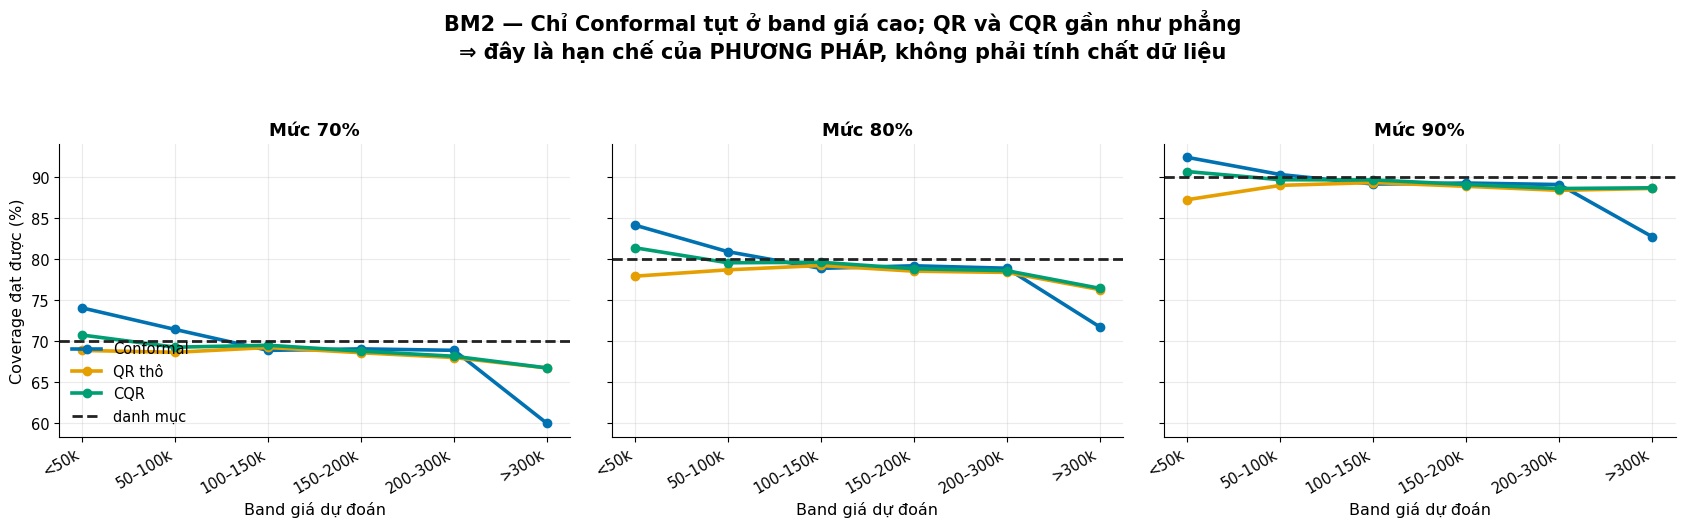

Coverage band THAP NHAT vs CAO NHAT o moi to hop:
  70% Conformal  : 59.95% (>300k) -> 74.04% (<50k)  | chenh 14.09 diem
  70% QR thô     : 66.72% (>300k) -> 69.22% (100–150k)  | chenh  2.50 diem
  70% CQR        : 66.72% (>300k) -> 70.73% (<50k)  | chenh  4.01 diem
  80% Conformal  : 71.74% (>300k) -> 84.14% (<50k)  | chenh 12.41 diem
  80% QR thô     : 76.27% (>300k) -> 79.22% (100–150k)  | chenh  2.95 diem
  80% CQR        : 76.43% (>300k) -> 81.38% (<50k)  | chenh  4.95 diem
  90% Conformal  : 82.72% (>300k) -> 92.40% (<50k)  | chenh  9.68 diem
  90% QR thô     : 87.25% (<50k) -> 89.34% (100–150k)  | chenh  2.09 diem
  90% CQR        : 88.61% (200–300k) -> 90.68% (<50k)  | chenh  2.07 diem


In [4]:
# ═════════ HINH BM2 — coverage theo band, 3 muc x 3 phuong phap ═════════
fig, ax = plt.subplots(1, 3, figsize=(17, 5), sharey=True)
MAU_PP = {"Conformal": BLUE, "QR thô": ORANGE, "CQR": GREEN}
x = np.arange(len(TEN))

for a, muc in zip(ax, MUCS):
    for pp in PP:
        g = BANG[(pp, muc)]
        a.plot(x, g.cvg*100, lw=2.6, marker="o", ms=6, color=MAU_PP[pp], label=pp)
    a.axhline(muc*100, color=INK, lw=2, ls="--", label="danh mục")
    a.set_xticks(x); a.set_xticklabels(TEN, rotation=30, ha="right")
    a.set_title(f"Mức {muc:.0%}", fontweight="bold")
    a.set_xlabel("Band giá dự đoán")
ax[0].set_ylabel("Coverage đạt được (%)")
ax[0].legend(frameon=False, loc="lower left")

fig.suptitle("BM2 — Chỉ Conformal tụt ở band giá cao; QR và CQR gần như phẳng\n"
             "⇒ đây là hạn chế của PHƯƠNG PHÁP, không phải tính chất dữ liệu",
             fontweight="bold", fontsize=15, y=1.05)
plt.tight_layout(); plt.savefig(HINH / "BM2_coverage_theo_band.png"); plt.show()

print("Coverage band THAP NHAT vs CAO NHAT o moi to hop:")
for muc in MUCS:
    for pp in PP:
        g = BANG[(pp, muc)]
        print(f"  {muc:.0%} {pp:11s}: {g.cvg.min():.2%} ({g.cvg.idxmin()}) "
              f"-> {g.cvg.max():.2%} ({g.cvg.idxmax()})  | chenh "
              f"{(g.cvg.max()-g.cvg.min())*100:5.2f} diem")

## 4. Bảng chi tiết — mức 90%, cả ba phương pháp

Đây là bảng đem vào báo cáo. Ba cột cuối là chỗ mentor sẽ đọc kỹ:
**hụt trên** = giá thật cao hơn cận trên (model hứa thấp), **hụt dưới** = ngược lại.

In [5]:
def in_bang(muc):
    rows = []
    for pp in PP:
        g = BANG[(pp, muc)]
        for b in TEN:
            r = g.loc[b]
            rows.append({
                "Phương pháp": pp, "Band": b, "n": f"{int(r.n):,}",
                "Coverage": f"{r.cvg:.2%}", "Lệch (điểm)": f"{r.lech:+.2f}",
                "Rộng TB (đ)": f"{r.rong_tb:,.0f}",
                "Rộng/giá": f"{r.rong_tuong_doi:.1%}",
                "Hụt trên": f"{r.hut_tren:.2%}", "Hụt dưới": f"{r.hut_duoi:.2%}"})
    return pd.DataFrame(rows)


B90 = in_bang(0.90)
print("MUC 90% — BANG CHI TIET")
display(B90)

MUC 90% — BANG CHI TIET


,Phương pháp,Band,n,Coverage,Lệch (điểm),Rộng TB (đ),Rộng/giá,Hụt trên,Hụt dưới
0,Conformal,<50k,"10,821",92.40%,+2.40,"26,293",60.2%,7.07%,0.53%
1,Conformal,50–100k,"264,201",90.31%,+0.31,"49,412",60.2%,7.26%,2.43%
2,Conformal,100–150k,"409,883",89.15%,-0.85,"73,435",60.2%,8.09%,2.76%
3,Conformal,150–200k,"149,324",89.27%,-0.73,"101,753",60.2%,8.03%,2.69%
4,Conformal,200–300k,"28,875",89.09%,-0.91,"134,783",60.2%,8.44%,2.47%
5,Conformal,>300k,"1,256",82.72%,-7.28,"201,911",60.2%,11.78%,5.49%
6,QR thô,<50k,"10,821",87.25%,-2.75,"24,989",57.2%,4.25%,8.50%
7,QR thô,50–100k,"264,201",88.99%,-1.01,"50,424",61.4%,5.12%,5.90%
8,QR thô,100–150k,"409,883",89.34%,-0.66,"77,820",63.8%,5.77%,4.89%
9,QR thô,150–200k,"149,324",88.87%,-1.13,"105,257",62.3%,6.63%,4.50%


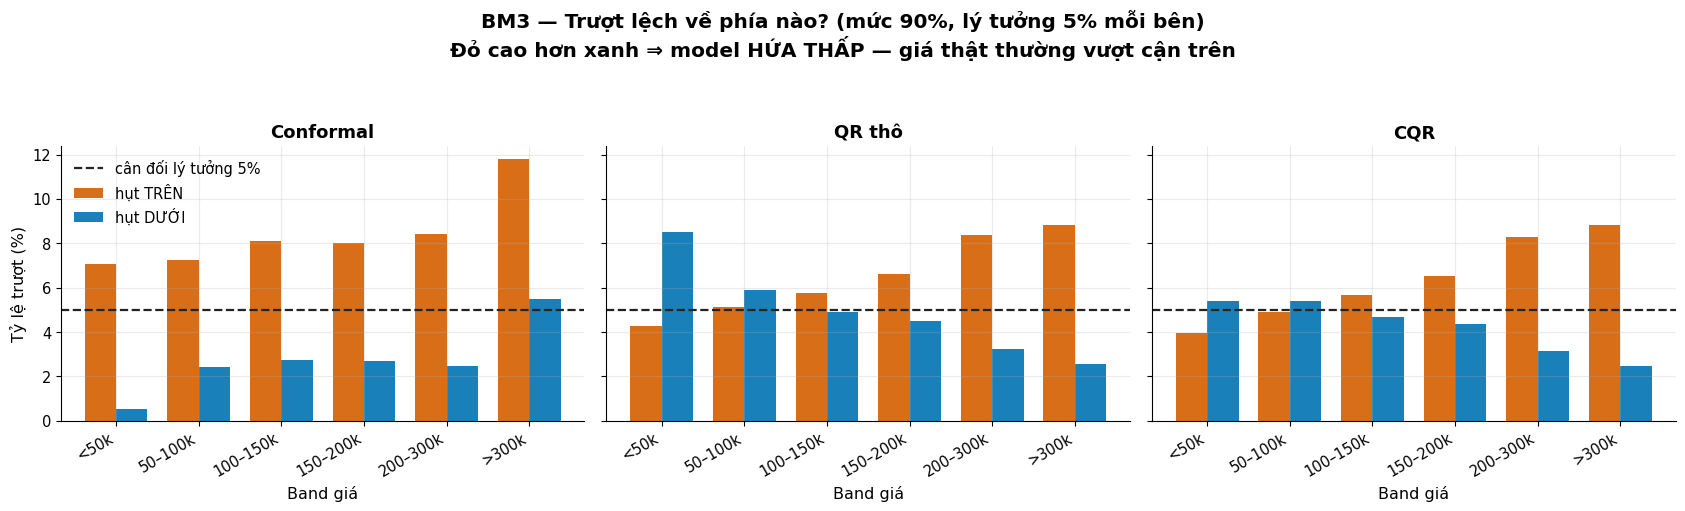

Conformal  : hut tren TB 8.44% · hut duoi TB 2.73% · ty le 3.1x
QR thô     : hut tren TB 6.50% · hut duoi TB 4.93% · ty le 1.3x
CQR        : hut tren TB 6.36% · hut duoi TB 4.24% · ty le 1.5x


In [6]:
# ═════════ HINH BM3 — bat doi xung: hut tren vs hut duoi ═════════
fig, ax = plt.subplots(1, 3, figsize=(17, 4.8), sharey=True)
for a, pp in zip(ax, PP):
    g = BANG[(pp, 0.90)]
    a.bar(x - .19, g.hut_tren*100, .38, color=RED, alpha=.9, label="hụt TRÊN")
    a.bar(x + .19, g.hut_duoi*100, .38, color=BLUE, alpha=.9, label="hụt DƯỚI")
    a.axhline(5, color=INK, lw=1.6, ls="--", label="cân đối lý tưởng 5%")
    a.set_xticks(x); a.set_xticklabels(TEN, rotation=30, ha="right")
    a.set_title(pp, fontweight="bold")
    a.set_xlabel("Band giá")
ax[0].set_ylabel("Tỷ lệ trượt (%)")
ax[0].legend(frameon=False)

fig.suptitle("BM3 — Trượt lệch về phía nào? (mức 90%, lý tưởng 5% mỗi bên)\n"
             "Đỏ cao hơn xanh ⇒ model HỨA THẤP — giá thật thường vượt cận trên",
             fontweight="bold", fontsize=14.5, y=1.06)
plt.tight_layout(); plt.savefig(HINH / "BM3_bat_doi_xung_3pp.png"); plt.show()

for pp in PP:
    g = BANG[(pp, 0.90)]
    print(f"{pp:11s}: hut tren TB {g.hut_tren.mean():.2%} · "
          f"hut duoi TB {g.hut_duoi.mean():.2%} · "
          f"ty le {g.hut_tren.mean()/max(g.hut_duoi.mean(),1e-9):.1f}x")

## 5. Kết luận

### Trả lời câu hỏi đặt ra ở đầu

Chạy cell dưới để lấy kết luận từ chính số vừa tính, không viết tay.

In [7]:
print("Band te nhat o tung to hop:")
for muc in MUCS:
    print(f"  {muc:.0%}: " + " · ".join(
        f"{pp} -> {BANG[(pp,muc)].cvg.idxmin()}" for pp in PP))

print()
print("Do DONG DEU giua cac band (lech toi da, diem) — cang nho cang tot:")
for pp in PP:
    v = [BANG[(pp, m)].lech.abs().max() for m in MUCS]
    print(f"  {pp:11s}: {' · '.join(f'{x:5.2f}' for x in v)}  -> TB {np.mean(v):.2f}")

print()
print("Nhung DONG DEU khong mien phi — do rong phai tra bao nhieu (muc 90%):")
for pp in PP:
    g = BANG[(pp, 0.90)]
    rong = (g.rong_tb * g.n).sum() / g.n.sum()
    print(f"  {pp:11s}: rong TB {rong:>8,.0f}d")

print()
print("=" * 70)
r_conf = (BANG[("Conformal", .90)].rong_tb * BANG[("Conformal", .90)].n).sum() / \
         BANG[("Conformal", .90)].n.sum()
r_cqr = (BANG[("CQR", .90)].rong_tb * BANG[("CQR", .90)].n).sum() / \
        BANG[("CQR", .90)].n.sum()
l_conf = np.mean([BANG[("Conformal", m)].lech.abs().max() for m in MUCS])
l_cqr = np.mean([BANG[("CQR", m)].lech.abs().max() for m in MUCS])
print("KET LUAN")
print("=" * 70)
print(f"  Conformal: dong deu {l_conf:.2f} diem · rong {r_conf:,.0f}d")
print(f"  CQR      : dong deu {l_cqr:.2f} diem · rong {r_cqr:,.0f}d")
print(f"  -> CQR deu hon {l_conf/l_cqr:.1f} lan, doi lay rong hon {r_cqr/r_conf-1:+.1%}")
print()
print("  Van de band gia KHONG phai tinh chat du lieu — QR va CQR gan nhu phang.")
print("  Nguyen nhan: Conformal chuan hoa ap MOT ty le q chung cho moi chuyen,")
print("  nen band gia cao (sai so tuong doi lon hon) bi cho khoang qua hep.")
print("  QR/CQR sinh phan vi RIENG cho tung chuyen nen tu thich ung.")

Band te nhat o tung to hop:
  70%: Conformal -> >300k · QR thô -> >300k · CQR -> >300k
  80%: Conformal -> >300k · QR thô -> >300k · CQR -> >300k
  90%: Conformal -> >300k · QR thô -> <50k · CQR -> 200–300k

Do DONG DEU giua cac band (lech toi da, diem) — cang nho cang tot:
  Conformal  : 10.05 ·  8.26 ·  7.28  -> TB 8.53
  QR thô     :  3.28 ·  3.73 ·  2.75  -> TB 3.25
  CQR        :  3.28 ·  3.57 ·  1.39  -> TB 2.75

Nhung DONG DEU khong mien phi — do rong phai tra bao nhieu (muc 90%):
  Conformal  : rong TB   72,630d
  QR thô     : rong TB   75,783d
  CQR        : rong TB   76,449d

KET LUAN
  Conformal: dong deu 8.53 diem · rong 72,630d
  CQR      : dong deu 2.75 diem · rong 76,449d
  -> CQR deu hon 3.1 lan, doi lay rong hon +5.3%

  Van de band gia KHONG phai tinh chat du lieu — QR va CQR gan nhu phang.
  Nguyen nhan: Conformal chuan hoa ap MOT ty le q chung cho moi chuyen,
  nen band gia cao (sai so tuong doi lon hon) bi cho khoang qua hep.
  QR/CQR sinh phan vi RIENG cho tung ch

### ⚠️ Kết quả này sửa lại kết luận tuần 3

Tuần 3 chọn **Conformal chuẩn hoá** làm phương pháp chính, vì nó cho khoảng **hẹp nhất** với
coverage tổng thể đạt danh mục. Đánh giá đó chỉ nhìn **coverage tổng thể** — đúng thứ mentor
phê bình ở ý 1.

Nhìn theo band thì bức tranh khác hẳn:

| Phương pháp | Lệch tối đa giữa band (TB 3 mức) | Độ rộng TB ở 90% |
|---|---:|---:|
| Conformal chuẩn hoá | **8,53 điểm** | hẹp nhất |
| QR thô | 3,25 điểm | — |
| **CQR** | **2,75 điểm** | rộng hơn |

Conformal áp **một tỷ lệ `q` chung** cho mọi chuyến, nên band giá cao — nơi sai số tương đối
lớn hơn — bị cho khoảng quá hẹp. QR và CQR sinh phân vị **riêng cho từng chuyến** nên tự thích ứng.

### Hai cách sửa, chọn cái nào

| | Cách | Lệch tối đa | Chi phí |
|---|---|---:|---|
| **A** | Giữ Conformal, thêm **Mondrian** (chia nhóm khi hiệu chỉnh) | 7,28 → **1,24 điểm** | +0,53% độ rộng |
| **B** | Chuyển sang **CQR** | **2,75 điểm** | rộng hơn Conformal, cần train 21 model quantile |

**A tốt hơn** — vừa đều hơn vừa rẻ hơn, và giữ nguyên hạ tầng hiện có. Chi tiết Mondrian ở
`uncertainty/07`.

### Cách nói với mentor

> *"Ở mức 90% model đạt coverage 89,6% — nhưng con số đó gộp cả band >300k chỉ đạt 82,7%.
> Chúng em kiểm cả 3 phương pháp × 3 mức tin cậy và phát hiện đây là hạn chế của **phương pháp**
> chứ không phải của dữ liệu: Conformal áp một tỷ lệ chung nên lệch tới 8,5 điểm giữa các band,
> còn CQR sinh phân vị riêng từng chuyến nên chỉ lệch 2,8 điểm. Cách sửa rẻ nhất là giữ Conformal
> nhưng hiệu chỉnh riêng theo nhóm (Mondrian) — lệch tối đa xuống 1,1 điểm, chỉ tốn 0,5% độ rộng."*

### Liên quan

| File | Vai trò |
|---|---|
| `07_uq_theo_band_gia.ipynb` | Phân rã band cho Conformal 90% + Mondrian |
| `06_ba_pp_ba_muc.ipynb` | So 3 phương pháp × 3 mức **trên tổng thể** (không phân rã band) |
| `08_uq_theo_thoi_gian.ipynb` | Phân rã theo thời gian |